# License Plate Detection
**CSC671 — Deep Learning Project**  
Team: David Lei, Luis Gabriel Ortiz-Anguiano, Ryan Kurian George

## Section 0: Colab Setup & Dataset Download

In [ ]:
import os

# ── Kaggle credentials ────────────────────────────────────────────────────────
# Replace these with your actual Kaggle username and API key
KAGGLE_USERNAME = 'luisitossb'
KAGGLE_KEY = 'KGAT_52289f388479276d732bec5244685129'

# ── Dataset ───────────────────────────────────────────────────────────────────
# Replace with the actual dataset slug from the Kaggle URL (username/dataset-name)
DATASET_SLUG = 'adilshamim8/license-plate-recognition'

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY

!pip install kaggle -q
!kaggle datasets download -d {DATASET_SLUG} --unzip -p data/raw/

print('Dataset downloaded and extracted to data/raw/')

Dataset URL: https://www.kaggle.com/datasets/adilshamim8/license-plate-recognition
License(s): Attribution 4.0 International (CC BY 4.0)
100% 502M/502M [00:29<00:00, 17.7MB/s]

Dataset downloaded and extracted to data/raw/


## Section 1: Data Exploration & Visualization

In [ ]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Paths
DATA_ROOT = os.path.join('data', 'raw')

TRAIN_DIR = os.path.join(DATA_ROOT, 'train', 'train')
VALID_DIR = os.path.join(DATA_ROOT, 'valid', 'valid')
TEST_DIR  = os.path.join(DATA_ROOT, 'test',  'test')

TRAIN_CSV = os.path.join(TRAIN_DIR, '_annotations.csv')
VALID_CSV = os.path.join(VALID_DIR, '_annotations.csv')
TEST_CSV  = os.path.join(TEST_DIR,  '_annotations.csv')

In [ ]:
# Load annotations
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f'Train samples : {len(train_df)}')
print(f'Valid samples : {len(valid_df)}')
print(f'Test  samples : {len(test_df)}')
print(f'Total         : {len(train_df) + len(valid_df) + len(test_df)}')
print()
print('Sample rows:')
train_df.head()

Train samples : 7357
Valid samples : 2195
Test  samples : 1085
Total         : 10637

Sample rows:


,filename,width,height,class,xmin,ymin,xmax,ymax
0,xemay1793_jpg.rf.0dc26bab2eb4bb60c25bf0430a744...,472,303,License_Plate,154,82,218,127
1,xemay1850_jpg.rf.a89277812aac9136da653af67d7e3...,472,303,License_Plate,187,122,249,169
2,rotatequandoi50_jpg.rf.fcc6a91af1b79436df370a0...,764,428,License_Plate,260,322,325,370
3,Cars354_png_jpg.rf.52d6d5fb18efb7075b02ccc55c4...,400,267,License_Plate,64,201,101,221
4,CarLongPlateGen2076_jpg.rf.2c1888f949cec4ec6e8...,472,303,License_Plate,316,242,412,271


In [ ]:
# Basic stats on bounding box sizes
train_df['box_width']  = train_df['xmax'] - train_df['xmin']
train_df['box_height'] = train_df['ymax'] - train_df['ymin']

print('Bounding box width  — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['box_width'].mean(), train_df['box_width'].min(), train_df['box_width'].max()))
print('Bounding box height — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['box_height'].mean(), train_df['box_height'].min(), train_df['box_height'].max()))
print()
print('Image width  — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['width'].mean(), train_df['width'].min(), train_df['width'].max()))
print('Image height — mean: {:.1f}, min: {}, max: {}'.format(
    train_df['height'].mean(), train_df['height'].min(), train_df['height'].max()))

Bounding box width  — mean: 123.8, min: 5, max: 3890
Bounding box height — mean: 63.2, min: 3, max: 1946

Image width  — mean: 593.2, min: 90, max: 5312
Image height — mean: 420.1, min: 86, max: 4608


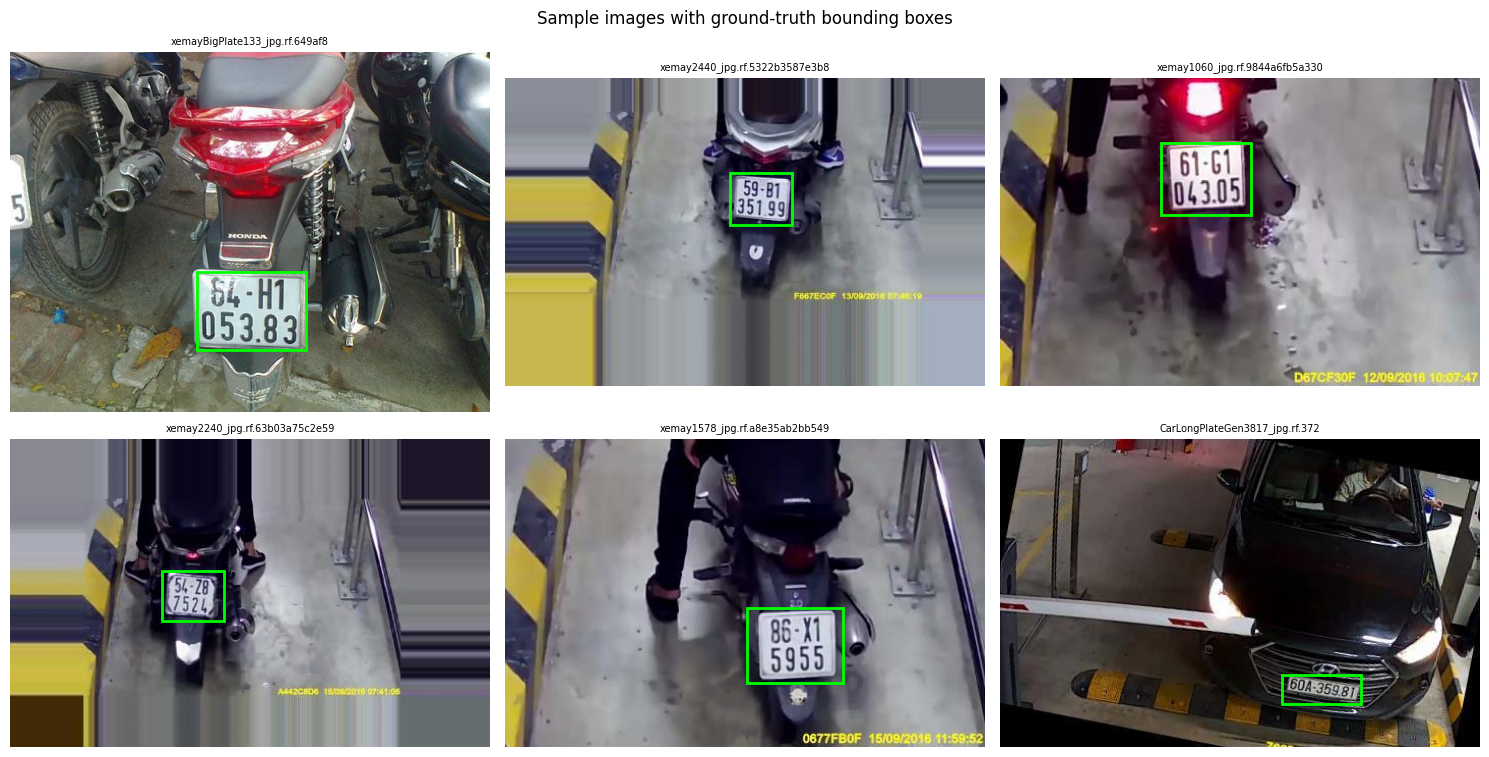

In [ ]:
def show_images_with_boxes(df, img_dir, n=6, cols=3):
    """Display n random images with their ground-truth bounding boxes."""
    samples = df.sample(n, random_state=42)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img_path = os.path.join(img_dir, row['filename'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        rect = patches.Rectangle(
            (row['xmin'], row['ymin']),
            row['xmax'] - row['xmin'],
            row['ymax'] - row['ymin'],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.set_title(row['filename'][:30], fontsize=7)
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('Sample images with ground-truth bounding boxes', fontsize=12)
    plt.tight_layout()
    plt.show()


show_images_with_boxes(train_df, TRAIN_DIR, n=6)

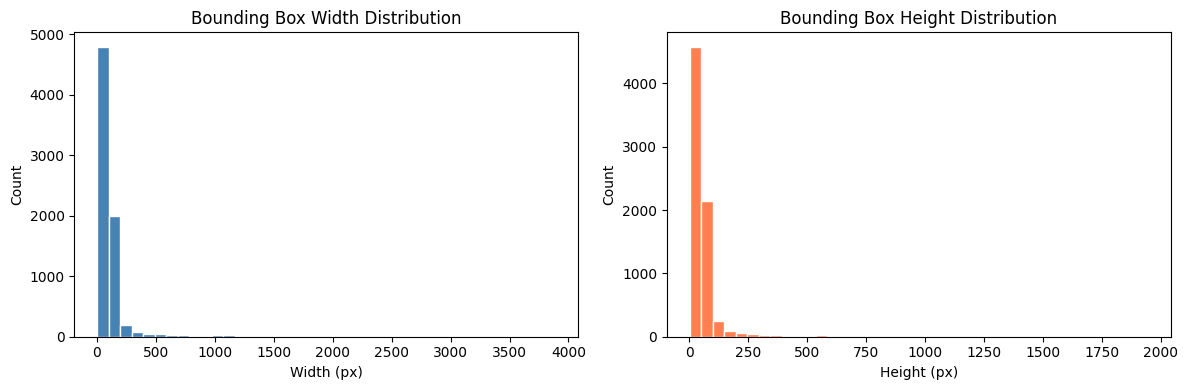

In [ ]:
# Distribution of bounding box sizes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['box_width'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Bounding Box Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(train_df['box_height'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Bounding Box Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Section 2: Dataset & DataLoader

We resize every image to a fixed size (224×224) so the model always receives the same input shape.
The bounding box coordinates are scaled to match the resized image, then normalized to [0, 1]
so the model outputs values in a consistent range regardless of original image size.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMG_SIZE = 224  # resize all images to this square size


class LicensePlateDataset(Dataset):
    def __init__(self, csv_path, img_dir, img_size=IMG_SIZE):
        self.df      = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = T.Compose([
            T.ToTensor(),                        # HWC uint8 -> CHW float [0,1]
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])  # ImageNet stats
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image and resize
        img_path = os.path.join(self.img_dir, row['filename'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        orig_w, orig_h = row['width'], row['height']
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Scale bounding box to resized image, then normalize to [0, 1]
        scale_x = self.img_size / orig_w
        scale_y = self.img_size / orig_h

        bbox = torch.tensor([
            (row['xmin'] * scale_x) / self.img_size,
            (row['ymin'] * scale_y) / self.img_size,
            (row['xmax'] * scale_x) / self.img_size,
            (row['ymax'] * scale_y) / self.img_size,
        ], dtype=torch.float32)

        image = self.transform(img)
        return image, bbox

In [ ]:
# Build datasets
train_dataset = LicensePlateDataset(TRAIN_CSV, TRAIN_DIR)
valid_dataset = LicensePlateDataset(VALID_CSV, VALID_DIR)
test_dataset  = LicensePlateDataset(TEST_CSV,  TEST_DIR)

# Build DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches : {len(train_loader)}')
print(f'Valid batches : {len(valid_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 230
Valid batches : 69
Test  batches : 34


In [ ]:
# Sanity check — load one batch and verify shapes
images, bboxes = next(iter(train_loader))

print(f'Image batch shape : {images.shape}')   # (32, 3, 224, 224)
print(f'BBox  batch shape : {bboxes.shape}')   # (32, 4)
print(f'BBox values (first sample): {bboxes[0]}')

Image batch shape : torch.Size([32, 3, 224, 224])
BBox  batch shape : torch.Size([32, 4])
BBox values (first sample): tensor([0.4809, 0.3828, 0.5508, 0.4785])


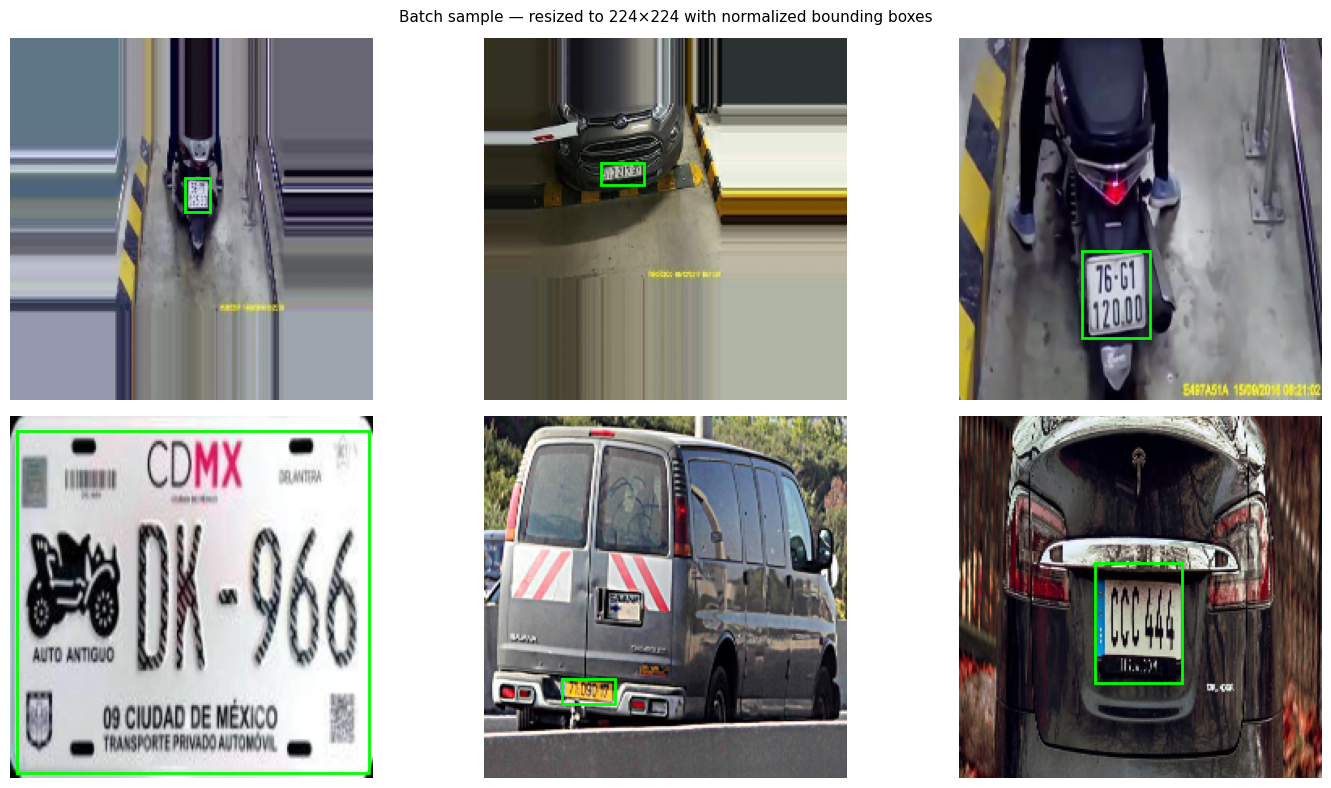

In [ ]:
# Visualize a batch to confirm boxes still look right after resizing
def show_batch(images, bboxes, n=6, cols=3):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i in range(n):
        img = images[i] * std + mean          # undo normalization
        img = img.permute(1, 2, 0).numpy()    # CHW -> HWC
        img = np.clip(img, 0, 1)

        xmin, ymin, xmax, ymax = bboxes[i].numpy() * IMG_SIZE  # back to pixels

        axes[i].imshow(img)
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        axes[i].add_patch(rect)
        axes[i].axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('Batch sample — resized to 224×224 with normalized bounding boxes', fontsize=11)
    plt.tight_layout()
    plt.show()


show_batch(images, bboxes, n=6)